In [192]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
#loading cleaned data
df = pd.read_csv('/content/marketing_clean_merge.csv')

In [194]:
df.brand.value_counts()

,count
brand,
purplle,44865
tira,44851
nykaa,44738


In [195]:
df.head()

,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,brand,total_acquisition_cost
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,207.355,2.82,Hindi,20.98,College Students,2025-04-29,nykaa,488321.025
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,3.26,Hindi,7.24,College Students,2025-04-06,nykaa,245386.310
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,1.88,English,25.03,College Students,2025-01-14,nykaa,68403.000
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,0.60,Hindi,13.15,College Students,2025-06-04,nykaa,235869.290
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29,nykaa,287578.800


In [196]:
df.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,total_acquisition_cost
count,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,1.344540e+05,134454.000000,134454.000000,134454.000000,1.344540e+05
mean,17.482946,55076.089733,4692.733210,1877.040326,1032.532301,5.156793e+05,371.357784,2.644594,13.767654,1.768408e+05
std,7.311916,25385.015904,3196.390777,1439.355725,864.159135,4.906331e+05,531.910822,4.421804,6.534609,8.157332e+04
min,5.000000,10001.000000,207.000000,48.000000,17.000000,3.895000e+03,9.340000,-0.990000,0.550000,6.842715e+03
25%,11.000000,33685.000000,2090.000000,771.000000,397.000000,1.763102e+05,110.322500,0.080000,8.240000,1.109275e+05
50%,17.000000,55182.500000,3884.000000,1468.000000,780.000000,3.586195e+05,209.060000,1.250000,13.520000,1.746874e+05
75%,24.000000,76513.750000,6733.000000,2620.000000,1414.000000,6.904160e+05,414.900000,3.420000,18.830000,2.380663e+05
max,30.000000,100000.000000,14888.000000,8876.000000,6686.000000,4.579910e+06,15038.000000,72.160000,53.480000,1.386376e+06


In [197]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134454 entries, 0 to 134453
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   campaign_type           134454 non-null  object        
 1   target_audience         134454 non-null  object        
 2   duration                134454 non-null  float64       
 3   channel_used            134454 non-null  object        
 4   impressions             134454 non-null  float64       
 5   clicks                  134454 non-null  float64       
 6   leads                   134454 non-null  float64       
 7   conversions             134454 non-null  float64       
 8   revenue                 134454 non-null  float64       
 9   acquisition_cost        134454 non-null  float64       
 10  roi                     134454 non-null  float64       
 11  language                134454 non-null  object        
 12  engagement_score        134454

In [199]:
df.isnull().sum()/df.shape[0]*100

,0
campaign_type,0.0
target_audience,0.0
duration,0.0
channel_used,0.0
impressions,0.0
clicks,0.0
leads,0.0
conversions,0.0
revenue,0.0
acquisition_cost,0.0


In [200]:
#adding profit flag
def check_profit(roi):
    if roi > 0:
        return "Profit"
    else:
        return "Loss"

df["profit_flag"] = df["roi"].apply(check_profit)

In [201]:
df['profit_flag'].value_counts()

,count
profit_flag,
Profit,103431
Loss,31023


In [202]:
df.head()

,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,...,language,engagement_score,customer_segment,date,brand,total_acquisition_cost,year,month,day,profit_flag
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,207.355,...,Hindi,20.98,College Students,2025-04-29,nykaa,488321.025,2025,4,29,Profit
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,...,Hindi,7.24,College Students,2025-04-06,nykaa,245386.310,2025,4,6,Profit
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,...,English,25.03,College Students,2025-01-14,nykaa,68403.000,2025,1,14,Profit
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,...,Hindi,13.15,College Students,2025-06-04,nykaa,235869.290,2025,6,4,Profit
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,...,Hindi,7.29,Tier 2 City Customers,2024-12-29,nykaa,287578.800,2024,12,29,Profit


In [203]:
base_cols = ["clicks", "leads", "conversions", "revenue", 'acquisition_cost', 'roi', 'engagement_score']
df[base_cols] = df[base_cols].fillna(0)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

In [204]:
df.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,date,total_acquisition_cost,year,month,day
count,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,1.344540e+05,134454.000000,134454.000000,134454.000000,134454,1.344540e+05,134454.000000,134454.000000,134454.000000
mean,17.482946,55076.089733,4692.733210,1877.040326,1032.532301,5.156793e+05,371.357784,2.644594,13.767654,2024-12-20 15:48:08.642955520,1.768408e+05,2024.467840,6.561352,15.524559
min,5.000000,10001.000000,207.000000,48.000000,17.000000,3.895000e+03,9.340000,-0.990000,0.550000,2024-07-01 00:00:00,6.842715e+03,2024.000000,1.000000,1.000000
25%,11.000000,33685.000000,2090.000000,771.000000,397.000000,1.763102e+05,110.322500,0.080000,8.240000,2024-09-25 00:00:00,1.109275e+05,2024.000000,3.000000,8.000000
50%,17.000000,55182.500000,3884.000000,1468.000000,780.000000,3.586195e+05,209.060000,1.250000,13.520000,2024-12-21 00:00:00,1.746874e+05,2024.000000,7.000000,15.000000
75%,24.000000,76513.750000,6733.000000,2620.000000,1414.000000,6.904160e+05,414.900000,3.420000,18.830000,2025-03-17 00:00:00,2.380663e+05,2025.000000,10.000000,23.000000
max,30.000000,100000.000000,14888.000000,8876.000000,6686.000000,4.579910e+06,15038.000000,72.160000,53.480000,2025-06-24 00:00:00,1.386376e+06,2025.000000,12.000000,31.000000
std,7.311916,25385.015904,3196.390777,1439.355725,864.159135,4.906331e+05,531.910822,4.421804,6.534609,NaN,8.157332e+04,0.498967,3.537703,8.802567


In [205]:
##feature engineering

df["click_through_rate"] = np.where(df["impressions"] > 0, (df["clicks"] / df["impressions"]) * 100, 0)
df["conversion_rate"] = np.where(df["clicks"] > 0, (df["conversions"] / df["clicks"]) * 100, 0)
df["lead_conversion_rate"] = np.where(df["leads"] > 0, (df["conversions"] / df["leads"]) * 100, 0)
df["cost_per_click"] = np.where(df["clicks"] > 0, df["acquisition_cost"] / df["clicks"], 0)
df["revenue_per_click"] = np.where(df["clicks"] > 0, df["revenue"] / df["clicks"], 0)
df["revenue_per_conversion"] = np.where(df["conversions"] > 0, df["revenue"] / df["conversions"], 0)
df["revenue_per_lead"] = np.where(df["leads"] > 0, df["revenue"] / df["leads"], 0)

#final cleanup to remove any nan or inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

In [206]:
print('New Feature:\n')
df[['click_through_rate', 'conversion_rate', 'lead_conversion_rate', "cost_per_click", "revenue_per_click", "revenue_per_conversion", "revenue_per_lead"]]

New Feature:



,click_through_rate,conversion_rate,lead_conversion_rate,cost_per_click,revenue_per_click,revenue_per_conversion,revenue_per_lead
0,10.649782,38.255361,65.127212,0.033683,303.365010,793.0,516.458794
1,3.617608,40.861186,68.848300,0.054450,315.039747,771.0,530.820396
2,14.044799,34.601283,79.306723,0.041522,90.309349,261.0,206.990546
3,9.547858,11.256389,42.447333,0.029605,44.800428,398.0,168.940385
4,3.863901,33.609404,61.067961,0.061074,138.470745,412.0,251.600000
...,...,...,...,...,...,...,...
134449,13.340551,27.463609,61.423221,0.009471,141.437589,515.0,316.329588
134450,10.561204,25.684398,56.347656,0.005917,89.124861,347.0,195.526367
134451,6.129149,32.263639,60.649652,0.027919,102.275734,317.0,192.259397
134452,7.987702,23.768283,54.573575,0.045766,141.896651,597.0,325.804242


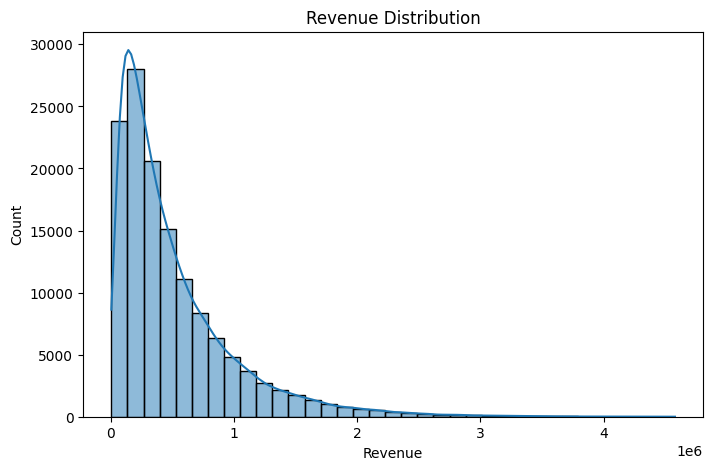

In [207]:
#findhing revenue disptribution
plt.figure(figsize=(8,5))
sns.histplot(df["revenue"], bins=35, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

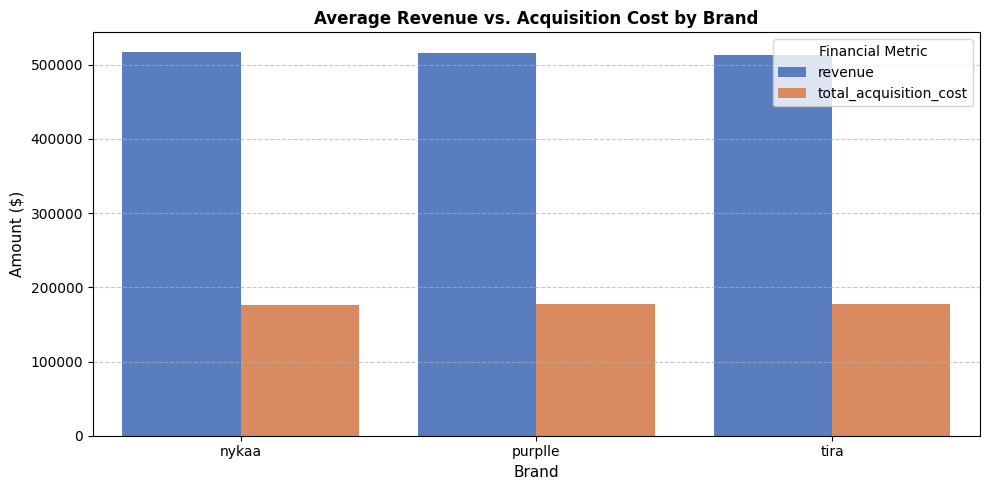

In [208]:
brand_summary = df.groupby("brand")[["revenue", "total_acquisition_cost"]].mean().reset_index()

brand_melted = brand_summary.melt(id_vars="brand", value_vars=["revenue", "total_acquisition_cost"],
                                  var_name="Metric", value_name="Average Amount")

plt.figure(figsize=(10, 5))
sns.barplot(data=brand_melted, x="brand", y="Average Amount", hue="Metric", palette="muted")

plt.title("Average Revenue vs. Acquisition Cost by Brand", fontsize=12, fontweight="bold")
plt.xlabel("Brand", fontsize=11)
plt.ylabel("Amount ($)", fontsize=11)
plt.legend(title="Financial Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [209]:
df.isnull().sum()

,0
campaign_type,0
target_audience,0
duration,0
channel_used,0
impressions,0
clicks,0
leads,0
conversions,0
revenue,0
acquisition_cost,0


In [210]:
df.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,date,...,year,month,day,click_through_rate,conversion_rate,lead_conversion_rate,cost_per_click,revenue_per_click,revenue_per_conversion,revenue_per_lead
count,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,1.344540e+05,134454.000000,134454.000000,134454.000000,134454,...,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000
mean,17.482946,55076.089733,4692.733210,1877.040326,1032.532301,5.156793e+05,371.357784,2.644594,13.767654,2024-12-20 15:48:08.642955520,...,2024.467840,6.561352,15.524559,8.501918,21.945088,54.961774,0.315031,109.649534,499.584468,274.579562
min,5.000000,10001.000000,207.000000,48.000000,17.000000,3.895000e+03,9.340000,-0.990000,0.550000,2024-07-01 00:00:00,...,2024.000000,1.000000,1.000000,0.398363,5.924171,28.813559,0.000663,12.790909,200.000000,59.965035
25%,11.000000,33685.000000,2090.000000,771.000000,397.000000,1.763102e+05,110.322500,0.080000,8.240000,2024-09-25 00:00:00,...,2024.000000,3.000000,8.000000,5.169141,15.250989,42.440758,0.017537,64.162771,349.000000,177.821374
50%,17.000000,55182.500000,3884.000000,1468.000000,780.000000,3.586195e+05,209.060000,1.250000,13.520000,2024-12-21 00:00:00,...,2024.000000,7.000000,15.000000,8.452102,20.502685,55.010988,0.052381,96.898010,498.500000,254.828227
75%,24.000000,76513.750000,6733.000000,2620.000000,1414.000000,6.904160e+05,414.900000,3.420000,18.830000,2025-03-17 00:00:00,...,2025.000000,10.000000,23.000000,11.788177,27.744839,67.447584,0.183910,142.470002,650.000000,355.887149
max,30.000000,100000.000000,14888.000000,8876.000000,6686.000000,4.579910e+06,15038.000000,72.160000,53.480000,2025-06-24 00:00:00,...,2025.000000,12.000000,31.000000,26.773586,47.869761,79.990672,56.714215,374.221871,800.000000,638.581680
std,7.311916,25385.015904,3196.390777,1439.355725,864.159135,4.906331e+05,531.910822,4.421804,6.534609,NaN,...,0.498967,3.537703,8.802567,3.882330,8.730594,14.441753,1.214816,59.897745,173.661936,122.191378


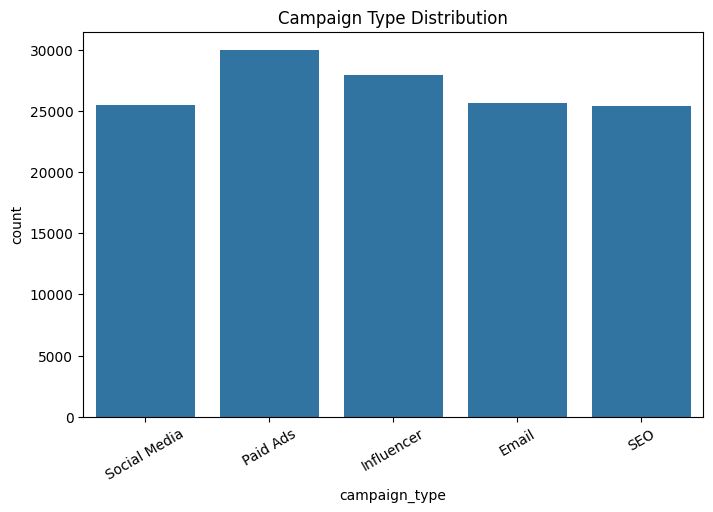

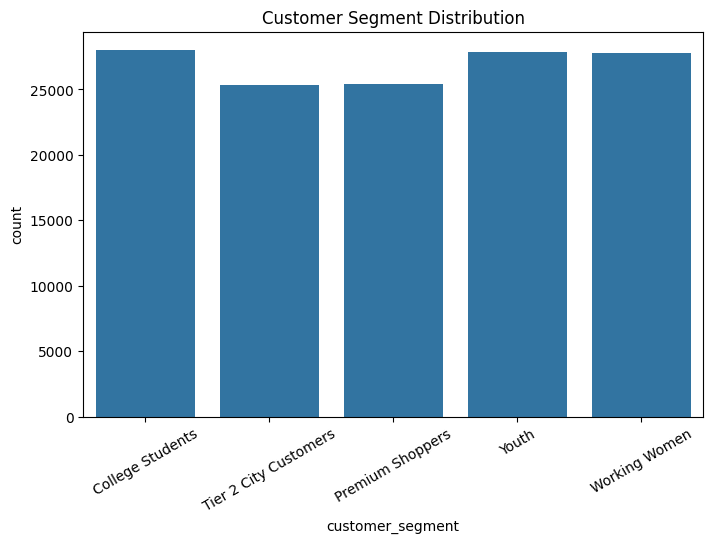

In [211]:
#distrubiton with campaign and customers
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="campaign_type")
plt.title("Campaign Type Distribution")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="customer_segment")
plt.title("Customer Segment Distribution")
plt.xticks(rotation=30)
plt.show()

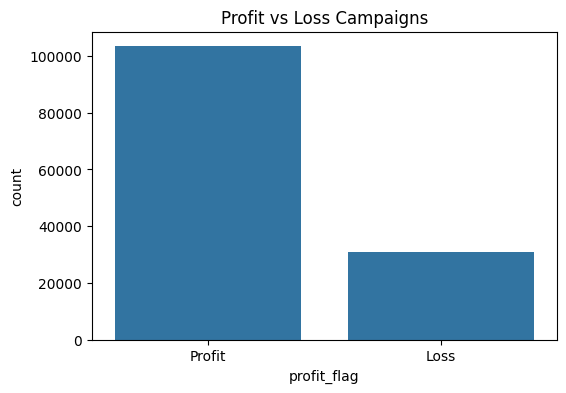

In [212]:
#profit vs loss

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="profit_flag")
plt.title("Profit vs Loss Campaigns")
plt.show()

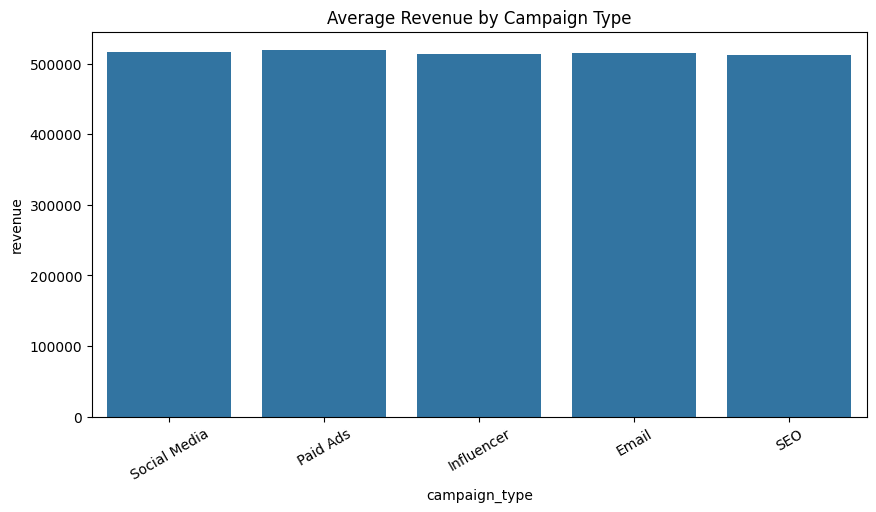

In [213]:
#campaign vs renue
plt.figure(figsize=(10,5))
sns.barplot(data=df,
            x="campaign_type",
            y="revenue",
            estimator="mean",
            errorbar=None)

plt.title("Average Revenue by Campaign Type")
plt.xticks(rotation=30)
plt.show()

In [214]:
df.brand.value_counts()

,count
brand,
purplle,44865
tira,44851
nykaa,44738


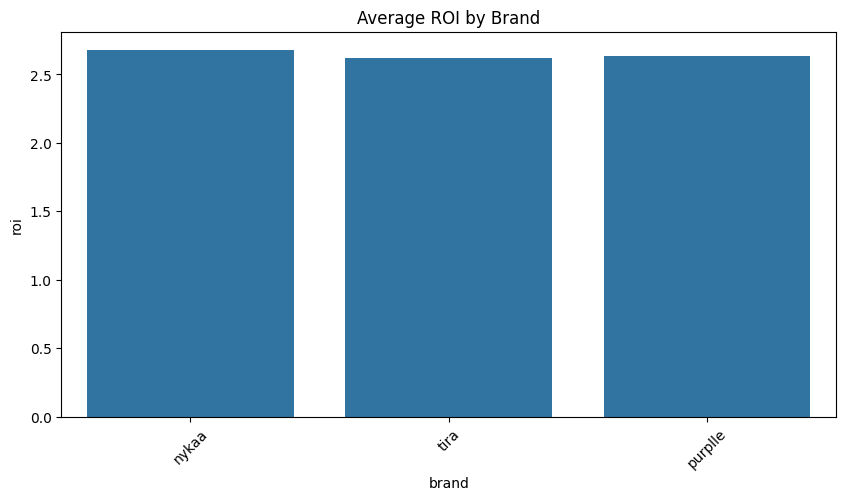

In [215]:
#roi by brand
plt.figure(figsize=(10,5))
sns.barplot(data=df,
            x="brand",
            y="roi",
            estimator="mean",
            errorbar=None)

plt.title("Average ROI by Brand")
plt.xticks(rotation=45)
plt.show()

In [216]:
df.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,date,...,year,month,day,click_through_rate,conversion_rate,lead_conversion_rate,cost_per_click,revenue_per_click,revenue_per_conversion,revenue_per_lead
count,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,1.344540e+05,134454.000000,134454.000000,134454.000000,134454,...,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000,134454.000000
mean,17.482946,55076.089733,4692.733210,1877.040326,1032.532301,5.156793e+05,371.357784,2.644594,13.767654,2024-12-20 15:48:08.642955520,...,2024.467840,6.561352,15.524559,8.501918,21.945088,54.961774,0.315031,109.649534,499.584468,274.579562
min,5.000000,10001.000000,207.000000,48.000000,17.000000,3.895000e+03,9.340000,-0.990000,0.550000,2024-07-01 00:00:00,...,2024.000000,1.000000,1.000000,0.398363,5.924171,28.813559,0.000663,12.790909,200.000000,59.965035
25%,11.000000,33685.000000,2090.000000,771.000000,397.000000,1.763102e+05,110.322500,0.080000,8.240000,2024-09-25 00:00:00,...,2024.000000,3.000000,8.000000,5.169141,15.250989,42.440758,0.017537,64.162771,349.000000,177.821374
50%,17.000000,55182.500000,3884.000000,1468.000000,780.000000,3.586195e+05,209.060000,1.250000,13.520000,2024-12-21 00:00:00,...,2024.000000,7.000000,15.000000,8.452102,20.502685,55.010988,0.052381,96.898010,498.500000,254.828227
75%,24.000000,76513.750000,6733.000000,2620.000000,1414.000000,6.904160e+05,414.900000,3.420000,18.830000,2025-03-17 00:00:00,...,2025.000000,10.000000,23.000000,11.788177,27.744839,67.447584,0.183910,142.470002,650.000000,355.887149
max,30.000000,100000.000000,14888.000000,8876.000000,6686.000000,4.579910e+06,15038.000000,72.160000,53.480000,2025-06-24 00:00:00,...,2025.000000,12.000000,31.000000,26.773586,47.869761,79.990672,56.714215,374.221871,800.000000,638.581680
std,7.311916,25385.015904,3196.390777,1439.355725,864.159135,4.906331e+05,531.910822,4.421804,6.534609,NaN,...,0.498967,3.537703,8.802567,3.882330,8.730594,14.441753,1.214816,59.897745,173.661936,122.191378


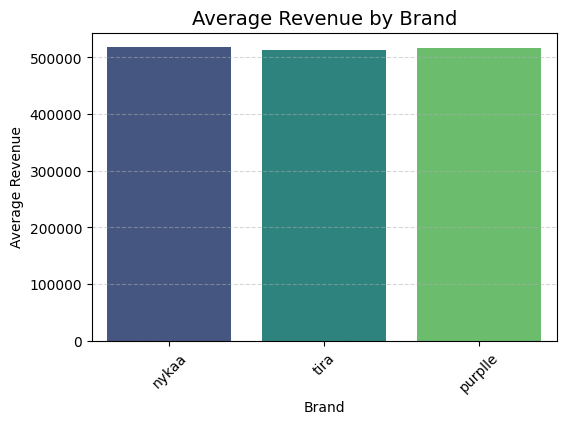

In [217]:
#revenue by brands
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="brand",
    y="revenue",
    estimator="mean",
    errorbar=None,
    palette="viridis"
)

plt.title("Average Revenue by Brand", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [218]:
df["revenue_log"] = np.log1p(df["revenue"])
df["acquisition_cost_log"] = np.log1p(df["acquisition_cost"])

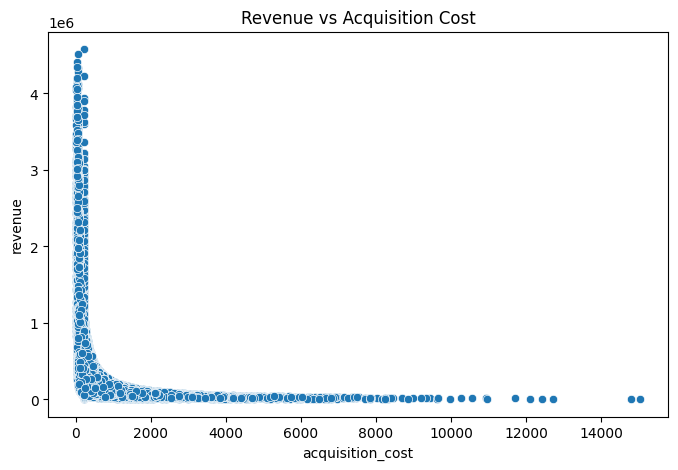

In [219]:
#Revenue vs Acquisition Cost
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="acquisition_cost",
                y="revenue")

plt.title("Revenue vs Acquisition Cost")
plt.show()

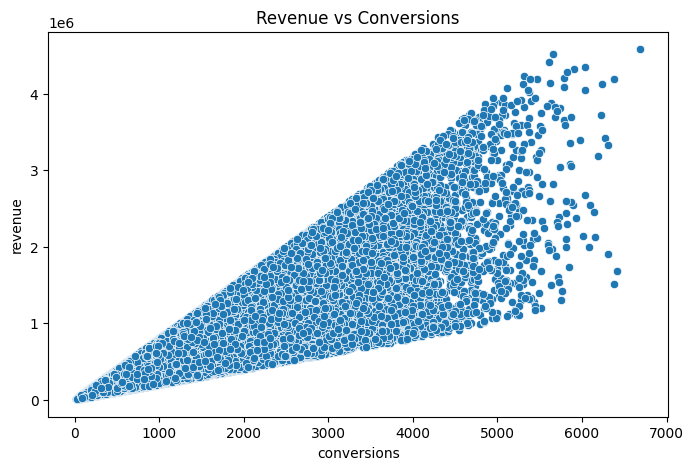

In [220]:
#Revenue vs Conversions
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="conversions",
                y="revenue")

plt.title("Revenue vs Conversions")
plt.show()

In [221]:
df[['revenue',
    'revenue_per_click',
    'revenue_per_lead',
    'revenue_per_conversion',
    'roi']].corr()['revenue'].sort_values(ascending=False)


,revenue
revenue,1.000000
roi,0.764100
revenue_per_click,0.580516
revenue_per_lead,0.470391
revenue_per_conversion,0.365231


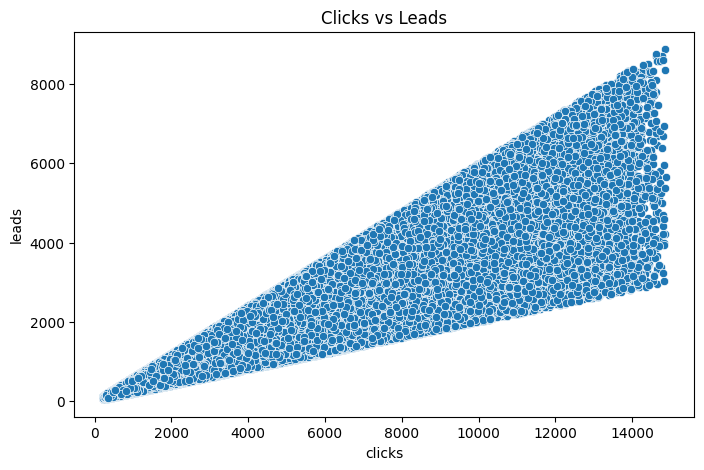

In [222]:
#Clicks vs Leads
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="clicks",
                y="leads")

plt.title("Clicks vs Leads")
plt.show()

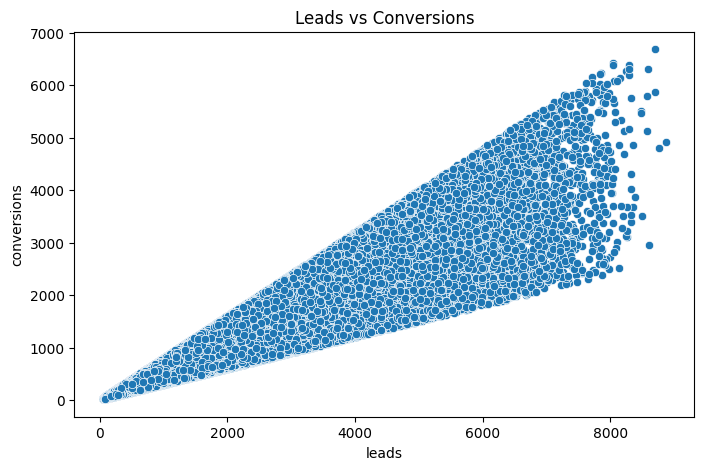

In [223]:
#Leads vs Conversions
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="leads",
                y="conversions")

plt.title("Leads vs Conversions")
plt.show()

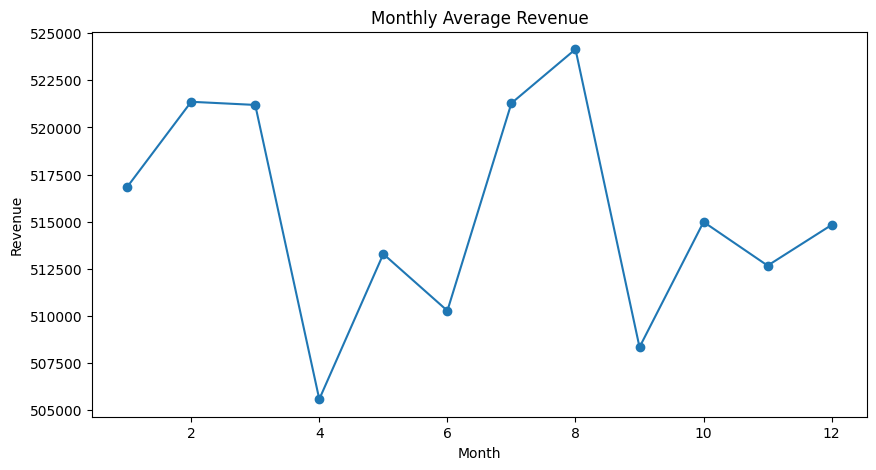

In [224]:
monthly = df.groupby(df["date"].dt.month)["revenue"].mean()

monthly.plot(marker="o", figsize=(10,5))
plt.title("Monthly Average Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

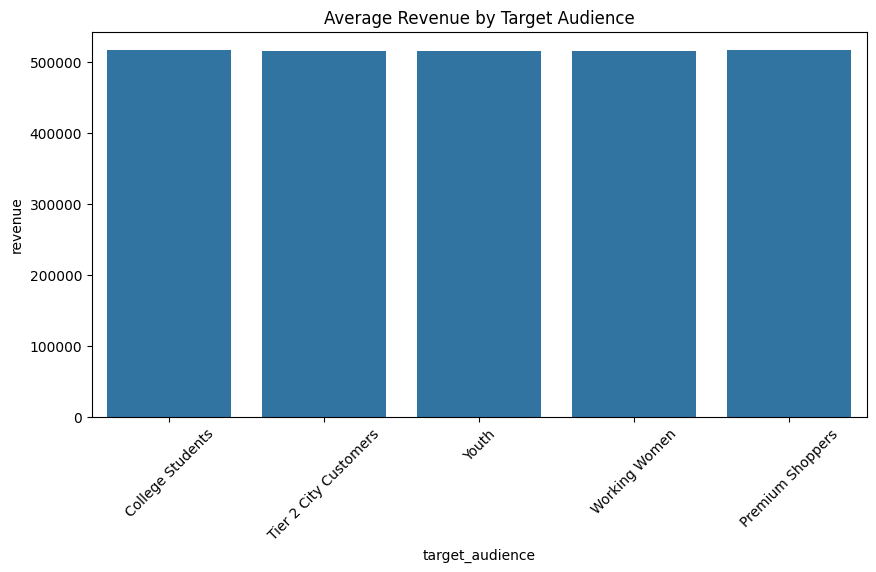

In [225]:
#Revenue by target audience
plt.figure(figsize=(10,5))
sns.barplot(data=df,
            x="target_audience",
            y="revenue",
            estimator="mean",
            errorbar=None)

plt.xticks(rotation=45)
plt.title("Average Revenue by Target Audience")
plt.show()

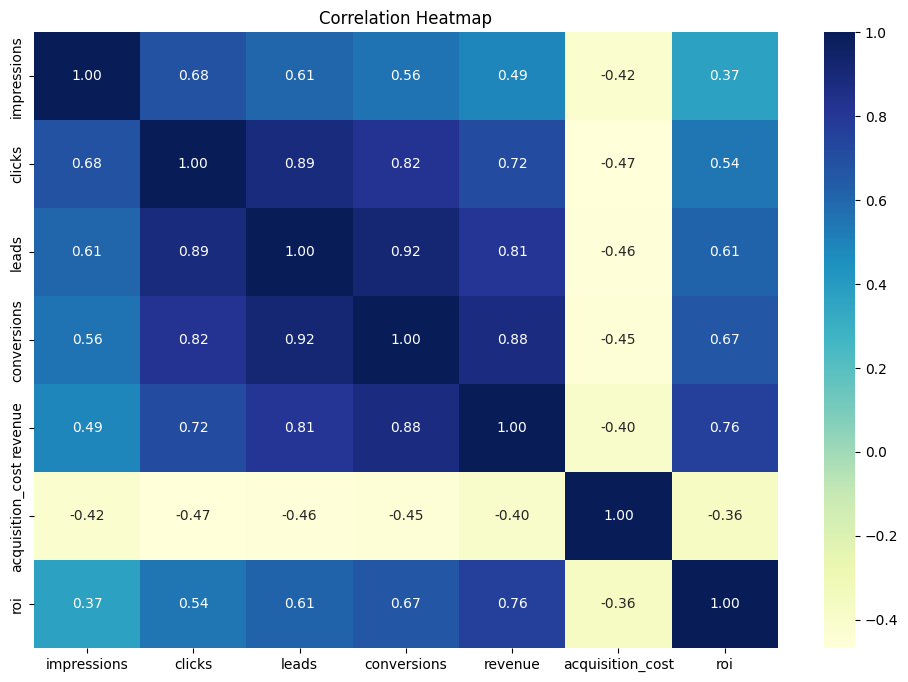

In [226]:
#heatmap of all numerical columns:
heatmap_cols = [
    "impressions",
    "clicks",
    "leads",
    "conversions",
    "revenue",
    "acquisition_cost",
    "roi"
]
plt.figure(figsize=(12,8))

corr = df[heatmap_cols].corr()
sns.heatmap(corr,
            annot=True,
            cmap="YlGnBu",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

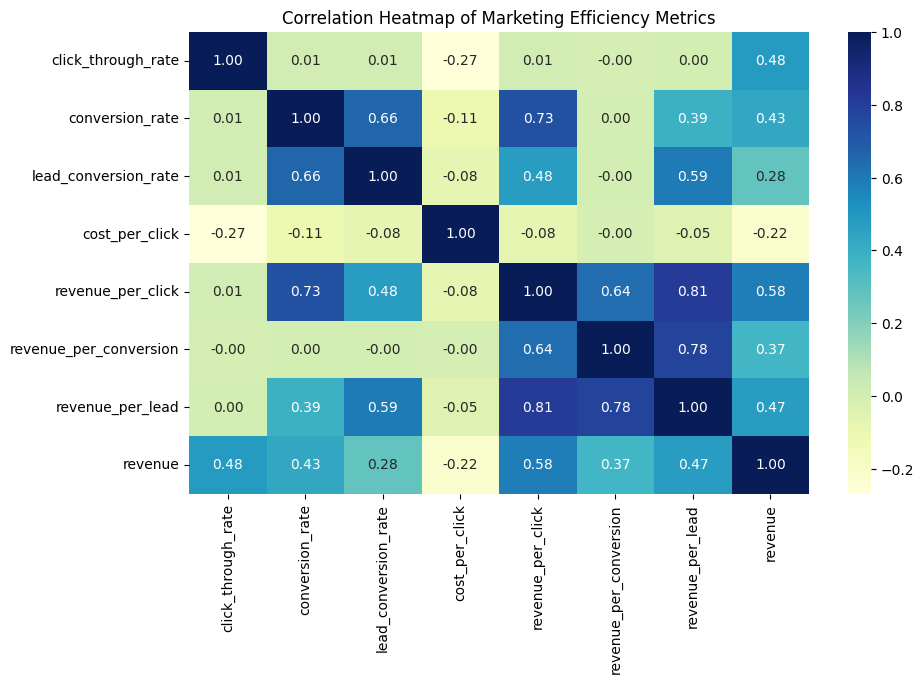

In [227]:
#heatmap for derived columns:
drv_cols = [
    "click_through_rate",
    "conversion_rate",
    "lead_conversion_rate",
    "cost_per_click",
    "revenue_per_click",
    "revenue_per_conversion",
    "revenue_per_lead",
    "revenue",
]

corr = df[drv_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Marketing Efficiency Metrics")
plt.show()

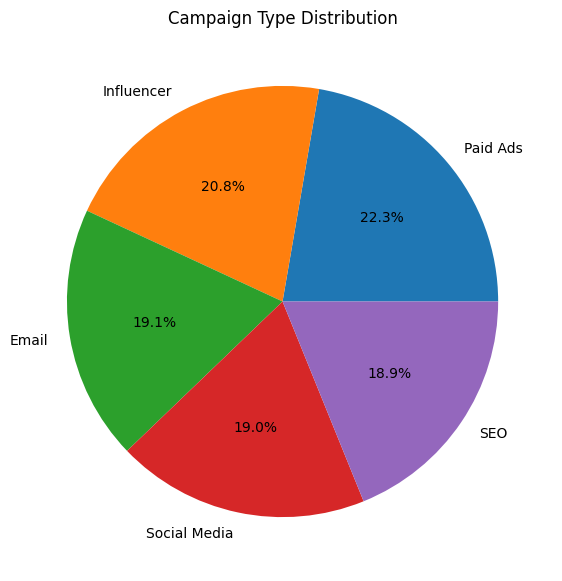

In [228]:
#campaign types
campaign_counts = df["campaign_type"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(campaign_counts,
        labels=campaign_counts.index,
        autopct="%1.1f%%")

plt.title("Campaign Type Distribution")
plt.show()

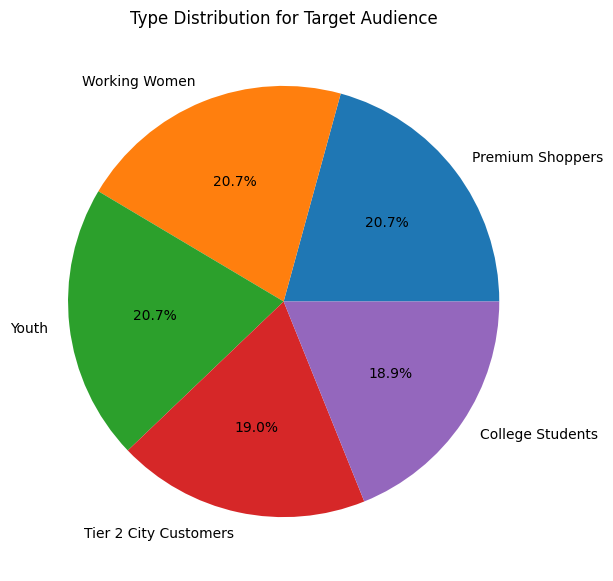

In [229]:
target_audience_counts = df["target_audience"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(target_audience_counts,
        labels=target_audience_counts.index,
        autopct="%1.1f%%")

plt.title("Type Distribution for Target Audience")
plt.show()

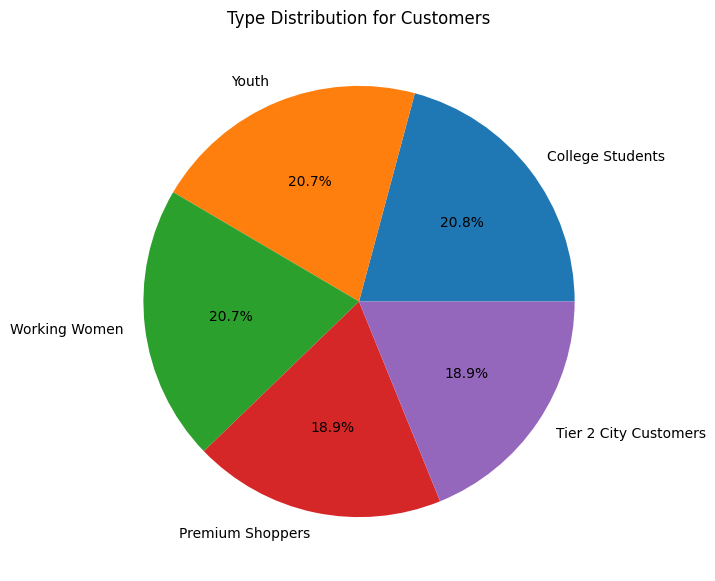

In [230]:
#customer_segment

customer_segment_counts = df["customer_segment"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(customer_segment_counts,
        labels=customer_segment_counts.index,
        autopct="%1.1f%%")

plt.title("Type Distribution for Customers")
plt.show()

In [231]:
df.columns

Index(['campaign_type', 'target_audience', 'duration', 'channel_used',
       'impressions', 'clicks', 'leads', 'conversions', 'revenue',
       'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand', 'total_acquisition_cost', 'year',
       'month', 'day', 'profit_flag', 'click_through_rate', 'conversion_rate',
       'lead_conversion_rate', 'cost_per_click', 'revenue_per_click',
       'revenue_per_conversion', 'revenue_per_lead', 'revenue_log',
       'acquisition_cost_log'],
      dtype='object')

In [232]:
df['customer_segment'].value_counts()

,count
customer_segment,
College Students,28008
Youth,27839
Working Women,27806
Premium Shoppers,25441
Tier 2 City Customers,25360


In [233]:
df.head()

,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,...,profit_flag,click_through_rate,conversion_rate,lead_conversion_rate,cost_per_click,revenue_per_click,revenue_per_conversion,revenue_per_lead,revenue_log,acquisition_cost_log
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,207.355,...,Profit,10.649782,38.255361,65.127212,0.033683,303.365010,793.0,516.458794,14.440120,5.339243
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,...,Profit,3.617608,40.861186,68.848300,0.054450,315.039747,771.0,530.820396,13.860721,5.203072
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,...,Profit,14.044799,34.601283,79.306723,0.041522,90.309349,261.0,206.990546,12.191243,4.517431
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,...,Profit,9.547858,11.256389,42.447333,0.029605,44.800428,398.0,168.940385,12.839754,5.521741
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,...,Profit,3.863901,33.609404,61.067961,0.061074,138.470745,412.0,251.600000,13.158304,5.436339


In [234]:
#all columns as list:
df.columns.tolist()

['campaign_type',
 'target_audience',
 'duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'language',
 'engagement_score',
 'customer_segment',
 'date',
 'brand',
 'total_acquisition_cost',
 'year',
 'month',
 'day',
 'profit_flag',
 'click_through_rate',
 'conversion_rate',
 'lead_conversion_rate',
 'cost_per_click',
 'revenue_per_click',
 'revenue_per_conversion',
 'revenue_per_lead',
 'revenue_log',
 'acquisition_cost_log']

In [235]:
#encoding:
df = pd.get_dummies(df, columns=["campaign_type"], dtype=int)
df = pd.get_dummies(df, columns=["target_audience"], dtype=int)
df = pd.get_dummies(df, columns=["brand"], dtype=int)
df = pd.get_dummies(df, columns=["customer_segment"], dtype=int)
df = pd.get_dummies(df, columns=["language"], dtype=int)


In [236]:
df.head()

,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score,...,brand_tira,customer_segment_College Students,customer_segment_Premium Shoppers,customer_segment_Tier 2 City Customers,customer_segment_Working Women,customer_segment_Youth,language_Bengali,language_English,language_Hindi,language_Tamil
0,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,207.355,2.82,20.98,...,0,1,0,0,0,0,0,0,1,0
1,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,3.26,7.24,...,0,1,0,0,0,0,0,0,1,0
2,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,1.88,25.03,...,0,1,0,0,0,0,0,1,0,0
3,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,0.60,13.15,...,0,1,0,0,0,0,0,0,1,0
4,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,0.80,7.29,...,0,0,0,1,0,0,0,0,1,0


In [237]:
df.columns.tolist()

['duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'engagement_score',
 'date',
 'total_acquisition_cost',
 'year',
 'month',
 'day',
 'profit_flag',
 'click_through_rate',
 'conversion_rate',
 'lead_conversion_rate',
 'cost_per_click',
 'revenue_per_click',
 'revenue_per_conversion',
 'revenue_per_lead',
 'revenue_log',
 'acquisition_cost_log',
 'campaign_type_Email',
 'campaign_type_Influencer',
 'campaign_type_Paid Ads',
 'campaign_type_SEO',
 'campaign_type_Social Media',
 'target_audience_College Students',
 'target_audience_Premium Shoppers',
 'target_audience_Tier 2 City Customers',
 'target_audience_Working Women',
 'target_audience_Youth',
 'brand_nykaa',
 'brand_purplle',
 'brand_tira',
 'customer_segment_College Students',
 'customer_segment_Premium Shoppers',
 'customer_segment_Tier 2 City Customers',
 'customer_segment_Working Women',
 'customer_segment_Youth',
 'language_Bengali',
 'language_English

In [238]:
df.isna().sum()

,0
duration,0
channel_used,0
impressions,0
clicks,0
leads,0
conversions,0
revenue,0
acquisition_cost,0
roi,0
engagement_score,0


In [239]:
df.dtypes[df.dtypes == "object"]

,0
channel_used,object
profit_flag,object


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134454 entries, 0 to 134453
Data columns (total 47 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   duration                                134454 non-null  float64       
 1   channel_used                            134454 non-null  object        
 2   impressions                             134454 non-null  float64       
 3   clicks                                  134454 non-null  float64       
 4   leads                                   134454 non-null  float64       
 5   conversions                             134454 non-null  float64       
 6   revenue                                 134454 non-null  float64       
 7   acquisition_cost                        134454 non-null  float64       
 8   roi                                     134454 non-null  float64       
 9   engagement_score                     

In [241]:
'''#multi label binary encoding:
from sklearn.preprocessing import MultiLabelBinarizer

df["channel_used"] = df["channel_used"].str.split(", ")

mlt = MultiLabelBinarizer()

channel_df = pd.DataFrame(
    mlt.fit_transform(df["channel_used"]),
    columns=mlt.classes_,
    index=df.index
)

df = pd.concat([df.drop("channel_used", axis=1),
                channel_df], axis=1)'''

'#multi label binary encoding:\nfrom sklearn.preprocessing import MultiLabelBinarizer\n\ndf["channel_used"] = df["channel_used"].str.split(", ")\n\nmlt = MultiLabelBinarizer()\n\nchannel_df = pd.DataFrame(\n    mlt.fit_transform(df["channel_used"]),\n    columns=mlt.classes_,\n    index=df.index\n)\n\ndf = pd.concat([df.drop("channel_used", axis=1),\n                channel_df], axis=1)'

In [242]:
df.columns.tolist()

['duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'engagement_score',
 'date',
 'total_acquisition_cost',
 'year',
 'month',
 'day',
 'profit_flag',
 'click_through_rate',
 'conversion_rate',
 'lead_conversion_rate',
 'cost_per_click',
 'revenue_per_click',
 'revenue_per_conversion',
 'revenue_per_lead',
 'revenue_log',
 'acquisition_cost_log',
 'campaign_type_Email',
 'campaign_type_Influencer',
 'campaign_type_Paid Ads',
 'campaign_type_SEO',
 'campaign_type_Social Media',
 'target_audience_College Students',
 'target_audience_Premium Shoppers',
 'target_audience_Tier 2 City Customers',
 'target_audience_Working Women',
 'target_audience_Youth',
 'brand_nykaa',
 'brand_purplle',
 'brand_tira',
 'customer_segment_College Students',
 'customer_segment_Premium Shoppers',
 'customer_segment_Tier 2 City Customers',
 'customer_segment_Working Women',
 'customer_segment_Youth',
 'language_Bengali',
 'language_English

In [243]:
df.columns.tolist()

['duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'engagement_score',
 'date',
 'total_acquisition_cost',
 'year',
 'month',
 'day',
 'profit_flag',
 'click_through_rate',
 'conversion_rate',
 'lead_conversion_rate',
 'cost_per_click',
 'revenue_per_click',
 'revenue_per_conversion',
 'revenue_per_lead',
 'revenue_log',
 'acquisition_cost_log',
 'campaign_type_Email',
 'campaign_type_Influencer',
 'campaign_type_Paid Ads',
 'campaign_type_SEO',
 'campaign_type_Social Media',
 'target_audience_College Students',
 'target_audience_Premium Shoppers',
 'target_audience_Tier 2 City Customers',
 'target_audience_Working Women',
 'target_audience_Youth',
 'brand_nykaa',
 'brand_purplle',
 'brand_tira',
 'customer_segment_College Students',
 'customer_segment_Premium Shoppers',
 'customer_segment_Tier 2 City Customers',
 'customer_segment_Working Women',
 'customer_segment_Youth',
 'language_Bengali',
 'language_English

##Model Building- Regression

In [244]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error,
                                     mean_absolute_error, r2_score,
                                     accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     confusion_matrix,
                                     classification_report)


In [245]:
# REGRESSION

reg_columns = [
    'duration',
    'impressions',
    'clicks',
    'leads',
    'conversions',
    'acquisition_cost',
    'engagement_score',
    'click_through_rate',
    'conversion_rate',
    'lead_conversion_rate',
    'cost_per_click',
    'campaign_type_Email',
    'campaign_type_Influencer',
    'campaign_type_Paid Ads',
    'campaign_type_SEO',
    'campaign_type_Social Media',
    'target_audience_College Students',
    'target_audience_Premium Shoppers',
    'target_audience_Tier 2 City Customers',
    'target_audience_Working Women',
    'target_audience_Youth',
    'brand_nykaa',
    'brand_purplle',
    'brand_tira',
    'language_Bengali',
    'language_English',
    'language_Hindi',
    'language_Tamil',
]


# Features and target
X = df[reg_columns]
y = df["revenue"]


In [246]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [247]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [248]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Regression": GradientBoostingRegressor(
        random_state=42
    )
}


In [249]:
#del results

In [250]:
results = {}

for name, model in models.items():

    # Linear models need scaling
    if name in ["Linear Regression", "Ridge Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Tree-based models don't need scaling
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }


# Results dataframe
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)


# Best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"\nBest Regression Model: {best_model_name}")

                              R2 Score            MAE           MSE  \
Ridge Regression              0.773358  154941.712433  5.481932e+10   
Linear Regression             0.773357  154941.785314  5.481944e+10   
Gradient Boosting Regression  0.771523  155308.065186  5.526311e+10   
Random Forest Regression      0.761802  157334.969396  5.761441e+10   

                                       RMSE  
Ridge Regression              234135.251036  
Linear Regression             234135.515302  
Gradient Boosting Regression  235081.069433  
Random Forest Regression      240030.018281  

Best Regression Model: Ridge Regression


In [251]:
best_regression_model = models["Ridge Regression"]

joblib.dump(
    best_regression_model,
    "best_regression_model.pkl"
)

['best_regression_model.pkl']

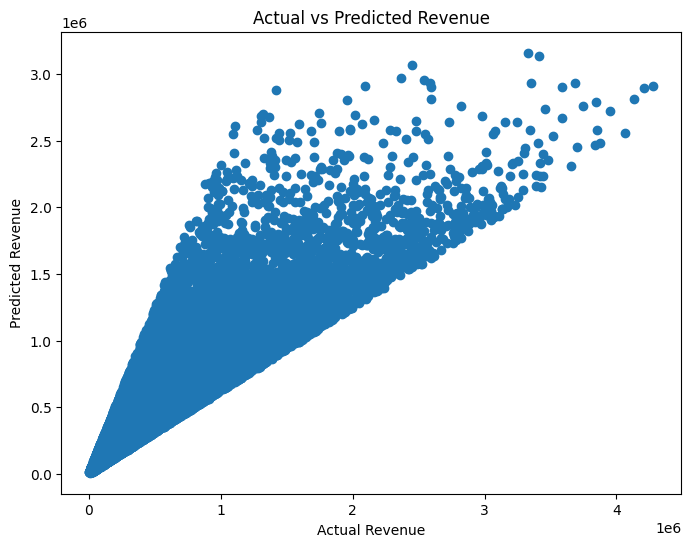

In [252]:
best_model = models["Ridge Regression"]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

##Classification

In [253]:
df.columns.tolist()

['duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'engagement_score',
 'date',
 'total_acquisition_cost',
 'year',
 'month',
 'day',
 'profit_flag',
 'click_through_rate',
 'conversion_rate',
 'lead_conversion_rate',
 'cost_per_click',
 'revenue_per_click',
 'revenue_per_conversion',
 'revenue_per_lead',
 'revenue_log',
 'acquisition_cost_log',
 'campaign_type_Email',
 'campaign_type_Influencer',
 'campaign_type_Paid Ads',
 'campaign_type_SEO',
 'campaign_type_Social Media',
 'target_audience_College Students',
 'target_audience_Premium Shoppers',
 'target_audience_Tier 2 City Customers',
 'target_audience_Working Women',
 'target_audience_Youth',
 'brand_nykaa',
 'brand_purplle',
 'brand_tira',
 'customer_segment_College Students',
 'customer_segment_Premium Shoppers',
 'customer_segment_Tier 2 City Customers',
 'customer_segment_Working Women',
 'customer_segment_Youth',
 'language_Bengali',
 'language_English

In [254]:
X = df.drop(columns=[
    "profit_flag",
    "roi",
    "revenue",
    "revenue_log",
    "revenue_per_click",
    "revenue_per_conversion",
    "revenue_per_lead",
    "channel_used",
    "date"
])
y = df["profit_flag"]

In [255]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['Loss' 'Profit']


In [256]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [257]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [258]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay


In [259]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [260]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [261]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [262]:
#del result

In [263]:
result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

result = result.sort_values(by="Accuracy", ascending=False)

print(result)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.912759   0.931529  0.956927  0.944058
2        Random Forest  0.911680   0.926254  0.961762  0.943674
1        Decision Tree  0.878770   0.920674  0.921831  0.921252


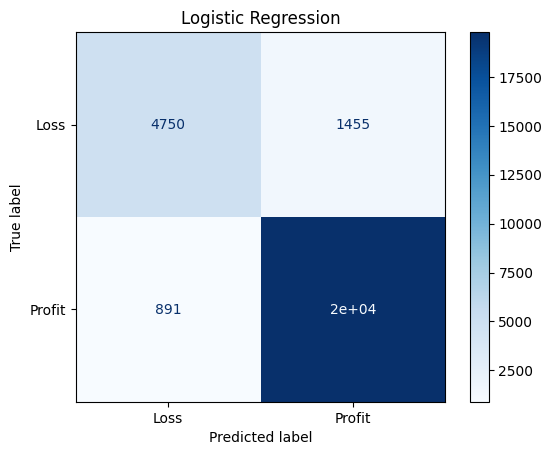

In [264]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Loss","Profit"],
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

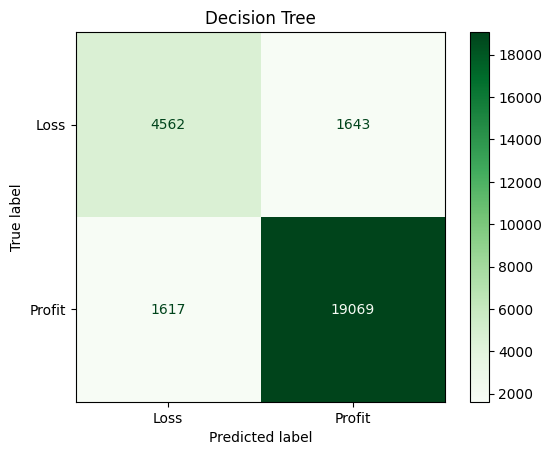

In [265]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["Loss","Profit"],
    cmap="Greens"
)

plt.title("Decision Tree")
plt.show()

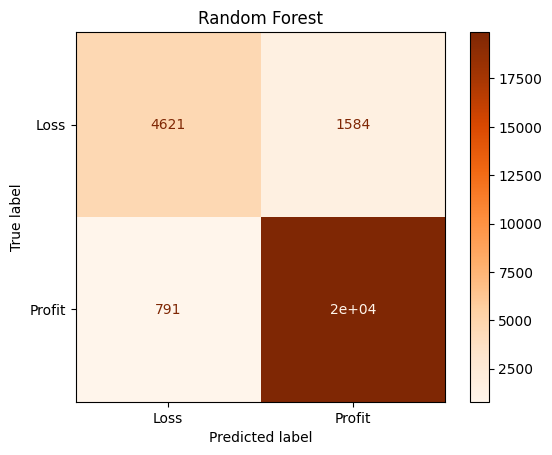

In [266]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Loss","Profit"],
    cmap="Oranges"
)

plt.title("Random Forest")
plt.show()

In [267]:
best_model = result.iloc[0]

print("Best Model\n")
print(best_model)

Best Model

Model        Logistic Regression
Accuracy                0.912759
Precision               0.931529
Recall                  0.956927
F1 Score                0.944058
Name: 0, dtype: object


In [268]:
best_model_name = result.iloc[0]["Model"]

print(best_model_name)

Logistic Regression


In [269]:
joblib.dump(
    scaler,
    "classification_scaler.pkl"
)

['classification_scaler.pkl']

In [270]:
joblib.dump(
    le,
    "label_encoder.pkl"
)

['label_encoder.pkl']

In [271]:
import joblib

joblib.dump(
    lr,
    "best_classification_model.pkl"
)

['best_classification_model.pkl']

In [272]:
print("sklearn version:", sklearn.__version__)

joblib.dump(
    best_regression_model,
    "best_regression_model.pkl"
)

sklearn version: 1.6.1


['best_regression_model.pkl']